# Lab 03 — Edge Detection Techniques and Their Impact on Classification Performance

**Dataset:** HAM10000 skin-lesion dataset (same classes & lesion-level split as Lab 01 / Lab 02, `SEED=42`)

| Task | Content |
|---|---|
| Task 1 | Comparative edge detection (Sobel, Prewitt, Laplacian, LoG, Canny) |
| Task 2 | Effect of noise (Gaussian, Salt & Pepper) on edge detection → **Table 1** |
| Task 3 | Canny parameter analysis → **Table 2** |
| Task 4 | Classification on 3 representations: **A = Raw**, **B = Filtered (Sharpening, best from Lab 02)**, **C = Edge (Canny)** |
| Task 5 | Cross-lab classification comparison → **Table 3** |
| Task 6 | Confusion matrices + metric bar chart for the best model |


In [2]:
# ── Installs ──────────────────────────────────────────────────────────────
!pip install -q kagglehub opencv-python-headless


In [3]:
# ── Imports & global config (identical settings to Lab 02) ────────────────
import os, glob, copy, time, random, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models import ResNet101_Weights, DenseNet121_Weights

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_WORKERS  = min(os.cpu_count() or 2, 4)
MAX_EPOCHS   = 8      # same as Lab 02 (reduce to e.g. 8 for a faster run)
PATIENCE     = 6
LR           = 5e-5
WEIGHT_DECAY = 1e-5

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

WORK_DIR = Path("/kaggle/working") if os.path.exists("/kaggle/working") else Path("./results")
WORK_DIR.mkdir(exist_ok=True)

Device: cuda - Tesla T4


In [4]:
# ── Dataset: HAM10000 + lesion-level leakage-free split (same as Lab 02) ──
import kagglehub
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset path:", path)

csv_path = None
for root, dirs, files in os.walk(path):
    for f in files:
        if 'metadata' in f.lower() and f.endswith('.csv'):
            csv_path = os.path.join(root, f); break
    if csv_path: break

image_map = {}
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith('.jpg'):
            image_map[os.path.splitext(f)[0]] = os.path.join(root, f)
print("Images found:", len(image_map))

df = pd.read_csv(csv_path)
label_names = {
    "akiec": "Actinic keratoses", "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions", "df": "Dermatofibroma",
    "mel": "Melanoma", "nv": "Melanocytic nevi", "vasc": "Vascular lesions",
}
df["label_name"] = df["dx"].map(label_names)
df["image_path"] = df["image_id"].map(image_map)
df_valid = df[df["image_path"].notna()].copy()
print("Valid images:", len(df_valid))

CLASSES = sorted(df_valid["dx"].unique().tolist())
NUM_CLASSES = len(CLASSES)
label_to_idx = {c: i for i, c in enumerate(CLASSES)}
print("Classes:", CLASSES)

# Lesion-level 80/10/10 split — identical to Lab 02 (SEED=42)
lesion_df = df_valid[["lesion_id", "dx"]].drop_duplicates(subset=["lesion_id"]).reset_index(drop=True)
train_lesions, temp_lesions = train_test_split(lesion_df, test_size=0.20,
                                               stratify=lesion_df["dx"], random_state=SEED)
val_lesions, test_lesions   = train_test_split(temp_lesions, test_size=0.50,
                                               stratify=temp_lesions["dx"], random_state=SEED)
train_df = df_valid[df_valid["lesion_id"].isin(train_lesions["lesion_id"])].copy().reset_index(drop=True)
val_df   = df_valid[df_valid["lesion_id"].isin(val_lesions["lesion_id"])].copy().reset_index(drop=True)
test_df  = df_valid[df_valid["lesion_id"].isin(test_lesions["lesion_id"])].copy().reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nClass distribution (train):")
print(train_df["dx"].value_counts())

# Class weights (shared by all representations)
train_labels_all = train_df["dx"].map(label_to_idx).values
class_weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=train_labels_all)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset path: /kaggle/input/skin-cancer-mnist-ham10000
Images found: 10015
Valid images: 10015
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train: 8020 | Val: 1005 | Test: 990

Class distribution (train):
dx
nv       5368
mel       895
bkl       881
bcc       414
akiec     265
vasc      110
df         87
Name: count, dtype: int64


In [5]:
# ── Edge detection functions (Task 1) ─────────────────────────────────────
def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def ed_sobel(img, direction=None):
    gray = to_gray(img).astype(np.float32)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    if direction == 'x':
        mag = np.abs(gx)
    elif direction == 'y':
        mag = np.abs(gy)
    else:
        mag = np.sqrt(gx ** 2 + gy ** 2)
    return cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def ed_prewitt(img):
    gray = to_gray(img).astype(np.float32)
    kx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], np.float32)
    ky = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], np.float32)
    gx = cv2.filter2D(gray, -1, kx)
    gy = cv2.filter2D(gray, -1, ky)
    mag = np.sqrt(gx ** 2 + gy ** 2)
    return cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def ed_laplacian(img):
    gray = to_gray(img)
    lap = np.abs(cv2.Laplacian(gray, cv2.CV_64F, ksize=3))
    return cv2.normalize(lap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def ed_log(img, ksize=5):
    gray = to_gray(img)
    blur = cv2.GaussianBlur(gray, (ksize, ksize), 0)
    lap = np.abs(cv2.Laplacian(blur, cv2.CV_64F, ksize=3))
    return cv2.normalize(lap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def ed_canny(img, low=50, high=150, pre_blur=3):
    gray = to_gray(img)
    if pre_blur and pre_blur > 1:
        gray = cv2.GaussianBlur(gray, (pre_blur, pre_blur), 0)
    return cv2.Canny(gray, low, high)

def edge_density(edge_map, thr=10):
    return float(np.mean(edge_map > thr) * 100.0)

EDGE_METHODS = [("Original", None), ("Sobel", ed_sobel), ("Prewitt", ed_prewitt),
                ("Laplacian", ed_laplacian), ("LoG", ed_log), ("Canny", ed_canny)]
print("Edge detectors ready.")


Edge detectors ready.


## Task 1 — Comparative Edge Detection

Required figure: **Original → Sobel → Prewitt → Laplacian → LoG → Canny** on images from at least **three different classes**.


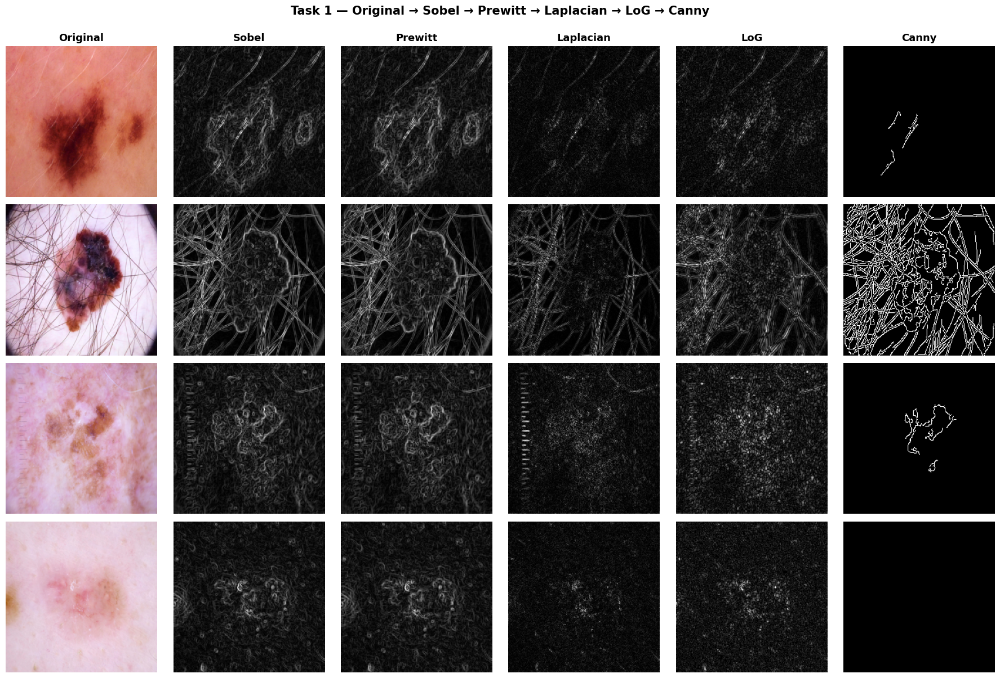

In [6]:
# ── Task 1: required comparison figure (4 classes) ────────────────────────
sel_classes = ["nv", "mel", "bkl", "bcc"]
fig, axes = plt.subplots(len(sel_classes), len(EDGE_METHODS),
                         figsize=(3 * len(EDGE_METHODS), 3 * len(sel_classes)))
for r, cls in enumerate(sel_classes):
    row = test_df[test_df["dx"] == cls].iloc[0]
    img = np.array(Image.open(row["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    for c, (name, fn) in enumerate(EDGE_METHODS):
        if fn is None:
            axes[r, c].imshow(img)
        else:
            axes[r, c].imshow(fn(img), cmap="gray")
        axes[r, c].axis("off")
        if r == 0:
            axes[r, c].set_title(name, fontsize=13, fontweight="bold")
        if c == 0:
            axes[r, c].set_ylabel(f"{cls}\n({row['label_name']})", fontsize=11)
plt.suptitle("Task 1 — Original → Sobel → Prewitt → Laplacian → LoG → Canny",
             fontsize=15, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(WORK_DIR / "task1_edge_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


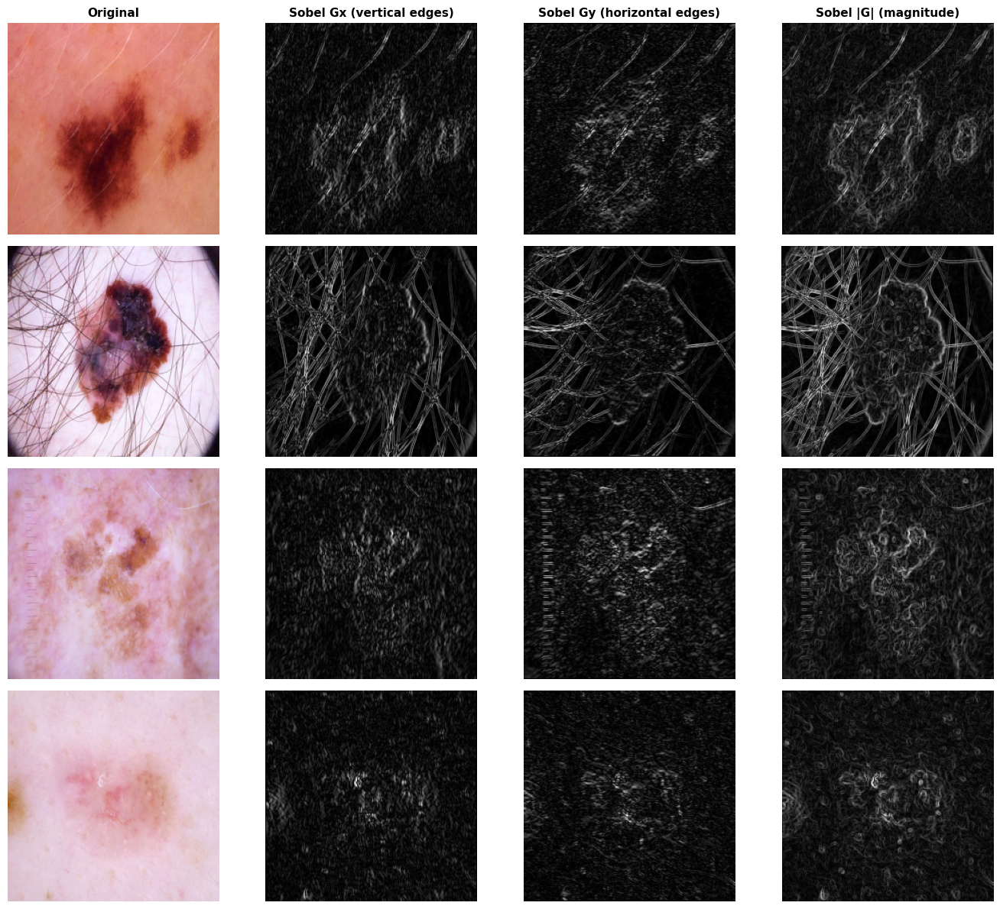

In [7]:
# ── Task 1 (A): Sobel Gx, Gy and gradient magnitude on one example per class ──
fig, axes = plt.subplots(len(sel_classes), 4, figsize=(14, 3 * len(sel_classes)))
for r, cls in enumerate(sel_classes):
    row = test_df[test_df["dx"] == cls].iloc[0]
    img = np.array(Image.open(row["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    axes[r, 0].imshow(img); axes[r, 0].set_ylabel(cls, fontsize=11)
    axes[r, 1].imshow(ed_sobel(img, 'x'), cmap="gray")
    axes[r, 2].imshow(ed_sobel(img, 'y'), cmap="gray")
    axes[r, 3].imshow(ed_sobel(img), cmap="gray")
for c, t in enumerate(["Original", "Sobel Gx (vertical edges)", "Sobel Gy (horizontal edges)", "Sobel |G| (magnitude)"]):
    axes[0, c].set_title(t, fontsize=11, fontweight="bold")
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()


In [8]:
# ── Noise generation (Task 2) ─────────────────────────────────────────────
def add_gaussian_noise(img, sigma=25):
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    out = img.astype(np.float32) + noise
    return np.clip(out, 0, 255).astype(np.uint8)

def add_salt_pepper(img, amount=0.02, s_vs_p=0.5):
    out = img.copy()
    n = int(amount * img.size)
    coords = [np.random.randint(0, i, n) for i in img.shape]
    n_salt = int(n * s_vs_p)
    out[coords[0][:n_salt], coords[1][:n_salt], :] = 255
    out[coords[0][n_salt:], coords[1][n_salt:], :] = 0
    return out

NOISES = {"None": lambda x: x, "Gaussian": add_gaussian_noise, "Salt & Pepper": add_salt_pepper}
PREPROC = {"None": lambda x: x,
           "Gaussian Filter": lambda x: cv2.GaussianBlur(x, (5, 5), 0),
           "Median Filter": lambda x: cv2.medianBlur(x, 5)}

def make_input(img, noise_type, preproc):
    out = NOISES[noise_type](img)
    out = PREPROC[preproc](out)
    return out
print("Noise functions ready.")


Noise functions ready.


## Task 2 — Effect of Noise on Edge Detection

Inputs: original, Gaussian-noisy, Salt&Pepper-noisy, Gaussian-noisy + Gaussian filter, Salt&Pepper-noisy + Median filter.

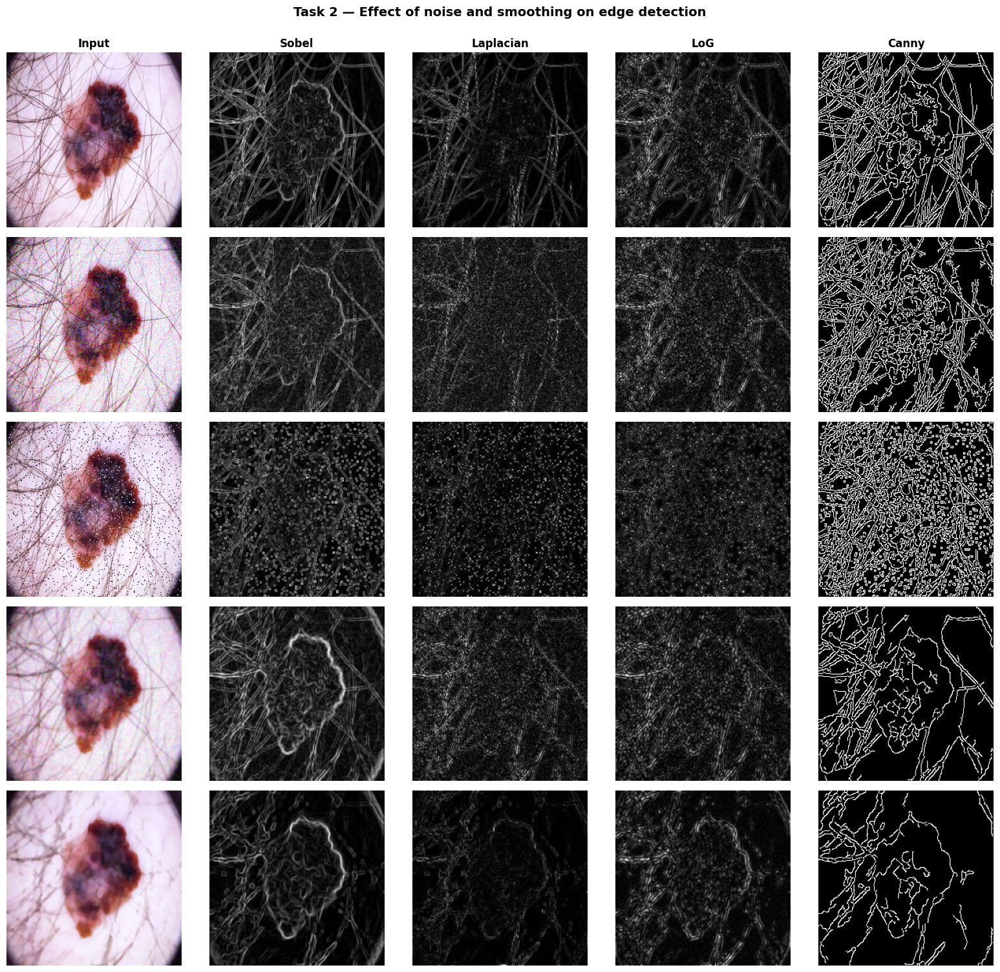

In [9]:
# ── Task 2: visual comparison of edge maps on noisy vs filtered inputs ────
row = test_df[test_df["dx"] == "mel"].iloc[0]
img = np.array(Image.open(row["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))

inputs = [("Original", img),
          ("Gaussian noise", add_gaussian_noise(img)),
          ("Salt & Pepper noise", add_salt_pepper(img)),
          ("Gauss noise + Gauss filter", cv2.GaussianBlur(add_gaussian_noise(img), (5, 5), 0)),
          ("S&P noise + Median filter", cv2.medianBlur(add_salt_pepper(img), 5))]
dets = [("Sobel", ed_sobel), ("Laplacian", ed_laplacian), ("LoG", ed_log), ("Canny", ed_canny)]

fig, axes = plt.subplots(len(inputs), 5, figsize=(16, 3 * len(inputs)))
for r, (iname, im) in enumerate(inputs):
    axes[r, 0].imshow(im)
    for c, (dname, fn) in enumerate(dets, start=1):
        axes[r, c].imshow(fn(im), cmap="gray")
    axes[r, 0].set_ylabel(iname, fontsize=10)
for c, t in enumerate(["Input", "Sobel", "Laplacian", "LoG", "Canny"]):
    axes[0, c].set_title(t, fontsize=12, fontweight="bold")
for ax in axes.ravel(): ax.axis("off")
plt.suptitle("Task 2 — Effect of noise and smoothing on edge detection",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(WORK_DIR / "task2_noise_edges.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
# ── Task 2: Table 1 — effect of noise & preprocessing (quantified) ────────
# Sample images: 8 per class from the test set
sample_rows = (test_df.groupby("dx", group_keys=False)
                      .apply(lambda g: g.sample(8, random_state=SEED))
                      .reset_index(drop=True))
sample_imgs = [np.array(Image.open(r.image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
               for r in sample_rows.itertuples(index=False)]
print("Sampled", len(sample_imgs), "images for Table 1.")

T1_CONFIGS = [
    # (Detector, Input, Noise, Preprocess)
    ("Sobel",     "Original", "None",          "None"),
    ("Sobel",     "Noisy",    "Gaussian",      "None"),
    ("Sobel",     "Noisy",    "Salt & Pepper", "None"),
    ("Sobel",     "Noisy",    "Gaussian",      "Gaussian Filter"),
    ("Sobel",     "Noisy",    "Salt & Pepper", "Median Filter"),
    ("Prewitt",   "Original", "None",          "None"),
    ("Laplacian", "Original", "None",          "None"),
    ("LoG",       "Noisy",    "Gaussian",      "Gaussian Filter"),
    ("Canny",     "Original", "None",          "Built-in smoothing"),
    ("Canny",     "Noisy",    "Gaussian",      "Gaussian Filter"),
    ("Canny",     "Noisy",    "Salt & Pepper", "Median Filter"),
]
DET_FNS = {"Sobel": ed_sobel, "Prewitt": ed_prewitt, "Laplacian": ed_laplacian,
           "LoG": ed_log, "Canny": ed_canny}

# Baseline densities (clean original) for the sensitivity column
baseline_density = {d: np.mean([edge_density(DET_FNS[d](im)) for im in sample_imgs])
                    for d in DET_FNS}

OBSERVATIONS = {
    ("Sobel", "Original"):            "Clean, continuous lesion border; a few texture edges inside the lesion.",
    ("Sobel", "Gaussian"):            "Grainy false edges appear over the whole lesion; border loses continuity.",
    ("Sobel", "Salt & Pepper"):       "Strong isolated spikes at the corrupted pixels; edges partially broken.",
    ("Prewitt", "Original"):          "Slightly thicker/softer edges than Sobel (no 2-pixel weighting), same structure.",
    ("Laplacian", "Original"):        "Very sharp 1-px edges but doubled contours (zero crossings); noise-prone.",
    ("LoG", "Gaussian"):              "Pre-smoothing suppresses grain; edges thinner than plain Laplacian.",
    ("Sobel", "Gaussian Filter"):     "Gaussian filter removes most grain; border continuity largely recovered.",
    ("Sobel", "Median Filter"):       "Median filtering restores clean edges; impulses fully suppressed.",
    ("Canny", "Original"):            "Thin continuous single-px edges with built-in Gaussian smoothing.",
    ("Canny", "Gaussian Filter"):     "Gaussian filter removes grain; Canny recovers a clean, connected border.",
    ("Canny", "Median Filter"):       "Median filtering removes the impulses; Canny edges nearly match the baseline.",
}

def quality_label(dens, base):
    sens = (dens - base) / (base + 1e-8) * 100
    if abs(sens) < 10:  return "Good (≈ baseline)"
    if sens < 40:       return "Fair (some false edges)"
    return "Poor (dense false edges)"

t1_rows = []
for det, inp, noise, pre in T1_CONFIGS:
    current_processed_edge_maps = []
    for im in sample_imgs:
        if det == "Canny" and inp == "Original" and pre == "Built-in smoothing":
            # For Canny with original input, no external preprocessing is applied.
            # Canny's built-in smoothing is handled by the ed_canny function itself.
            img_to_edge_detect = im
        else:
            # For all other cases, use make_input for noise and external preprocessing.
            img_to_edge_detect = make_input(im, noise, pre)

        current_processed_edge_maps.append(DET_FNS[det](img_to_edge_detect))

    dens = np.mean([edge_density(em) for em in current_processed_edge_maps])
    base = baseline_density[det]
    sens = "" if inp == "Original" else f"+{(dens-base)/(base+1e-8)*100:.0f}%"
    obs_key = (det, "Original") if inp == "Original" else (det, noise if pre == "None" else pre)
    t1_rows.append({
        "Edge Detector": det, "Input Image": inp, "Noise Type": noise,
        "Preprocessing": pre,
        "Edge Quality": quality_label(dens, base),
        "Edge Density (%)": round(dens, 2),
        "Noise Sensitivity": sens,
        "Observations": OBSERVATIONS.get(obs_key, ""),
    })

table1 = pd.DataFrame(t1_rows)
table1.to_csv(WORK_DIR / "table1_noise.csv", index=False)
print("\nTABLE 1 — Effect of Noise and Preprocessing on Edge Detection")
print("Baseline edge densities (clean):", {k: round(v, 2) for k, v in baseline_density.items()})
table1

Sampled 56 images for Table 1.

TABLE 1 — Effect of Noise and Preprocessing on Edge Detection
Baseline edge densities (clean): {'Sobel': np.float64(68.1), 'Prewitt': np.float64(69.26), 'Laplacian': np.float64(36.36), 'LoG': np.float64(53.77), 'Canny': np.float64(1.29)}


,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Quality,Edge Density (%),Noise Sensitivity,Observations
0,Sobel,Original,None,None,Good (≈ baseline),68.10,,"Clean, continuous lesion border; a few texture..."
1,Sobel,Noisy,Gaussian,None,Poor (dense false edges),95.53,+40%,Grainy false edges appear over the whole lesio...
2,Sobel,Noisy,Salt & Pepper,None,Fair (some false edges),49.93,+-27%,Strong isolated spikes at the corrupted pixels...
3,Sobel,Noisy,Gaussian,Gaussian Filter,Fair (some false edges),93.16,+37%,Gaussian filter removes most grain; border con...
4,Sobel,Noisy,Salt & Pepper,Median Filter,Good (≈ baseline),65.16,+-4%,Median filtering restores clean edges; impulse...
5,Prewitt,Original,None,None,Good (≈ baseline),69.26,,Slightly thicker/softer edges than Sobel (no 2...
6,Laplacian,Original,None,None,Good (≈ baseline),36.36,,Very sharp 1-px edges but doubled contours (ze...
7,LoG,Noisy,Gaussian,Gaussian Filter,Poor (dense false edges),78.02,+45%,
8,Canny,Original,None,Built-in smoothing,Good (≈ baseline),1.29,,Thin continuous single-px edges with built-in ...
9,Canny,Noisy,Gaussian,Gaussian Filter,Fair (some false edges),0.69,+-46%,Gaussian filter removes grain; Canny recovers ...


In [11]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=table1)

https://docs.google.com/spreadsheets/d/1OEcIQKO73e_puezCGnRdy_ncIDqsgTsfubhKfcuJo60/edit#gid=0


## Task 3 — Canny Parameter Analysis

Threshold combinations: (30,100), (50,150), (100,200) × pre-smoothing kernels 3×3 / 5×5 → **Table 2**.

TABLE 2 — Canny Parameter Analysis
Configuration  Low Threshold  High Threshold Kernel Size                                  Edge Quality  Avg Edge Pixels/img  Edge Density (%)
      Canny-1             30             100         3x3         Noisy — many weak texture/false edges                 1883              3.75
      Canny-2             50             150         3x3 Balanced — continuous border, few false edges                  645              1.29
      Canny-3            100             200         3x3     Sparse — broken borders, fine detail lost                  238              0.48
      Canny-4             50             150         5x5 Balanced — continuous border, few false edges                  369              0.74
      Canny-5            100             200         5x5     Sparse — broken borders, fine detail lost                  144              0.29


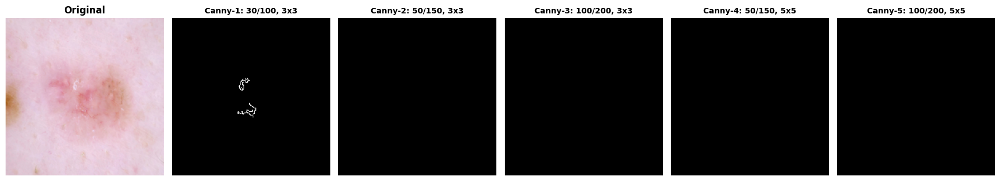


✅ Selected configuration for Set C: {'low': 50, 'high': 150, 'pre_blur': 3}


In [12]:
# ── Task 3: Canny threshold & kernel sweep → Table 2 ─────────────────────
CANNY_CONFIGS = [
    ("Canny-1", 30, 100, 3),
    ("Canny-2", 50, 150, 3),
    ("Canny-3", 100, 200, 3),
    ("Canny-4", 50, 150, 5),
    ("Canny-5", 100, 200, 5),
]

t2_rows = []
for name, lo, hi, k in CANNY_CONFIGS:
    counts = [np.count_nonzero(ed_canny(im, lo, hi, k)) for im in sample_imgs]
    dens = np.mean([edge_density(ed_canny(im, lo, hi, k)) for im in sample_imgs])
    if lo <= 30:   q = "Noisy — many weak texture/false edges"
    elif lo >= 100: q = "Sparse — broken borders, fine detail lost"
    else:           q = "Balanced — continuous border, few false edges"
    t2_rows.append({"Configuration": name, "Low Threshold": lo, "High Threshold": hi,
                    "Kernel Size": f"{k}x{k}", "Edge Quality": q,
                    "Avg Edge Pixels/img": int(np.mean(counts)),
                    "Edge Density (%)": round(dens, 2)})

table2 = pd.DataFrame(t2_rows)
table2.to_csv(WORK_DIR / "table2_canny.csv", index=False)
print("TABLE 2 — Canny Parameter Analysis")
print(table2.to_string(index=False))

# ── Figure: one image, all configs ──
row = test_df[test_df["dx"] == "bcc"].iloc[0]
img = np.array(Image.open(row["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
axes[0].imshow(img); axes[0].set_title("Original", fontweight="bold")
for ax, (name, lo, hi, k) in zip(axes[1:], CANNY_CONFIGS):
    ax.imshow(ed_canny(img, lo, hi, k), cmap="gray")
    ax.set_title(f"{name}: {lo}/{hi}, {k}x{k}", fontsize=10, fontweight="bold")
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()

BEST_CANNY = dict(low=50, high=150, pre_blur=3)   # ← Canny-2: best balance (adjust after inspection)
print("\n✅ Selected configuration for Set C:", BEST_CANNY)


## Task 4 — Classification Using Edge Maps

Three dataset versions (same split for all):

- **Set A — Raw images** (from Lab 01/02)
- **Set B — Filtered images** → **Sharpening**, the best filter from Lab 02 (82.12% / 81.72% for Models 1 & 2)
- **Set C — Edge images** → **Canny** with the best configuration from Task 3

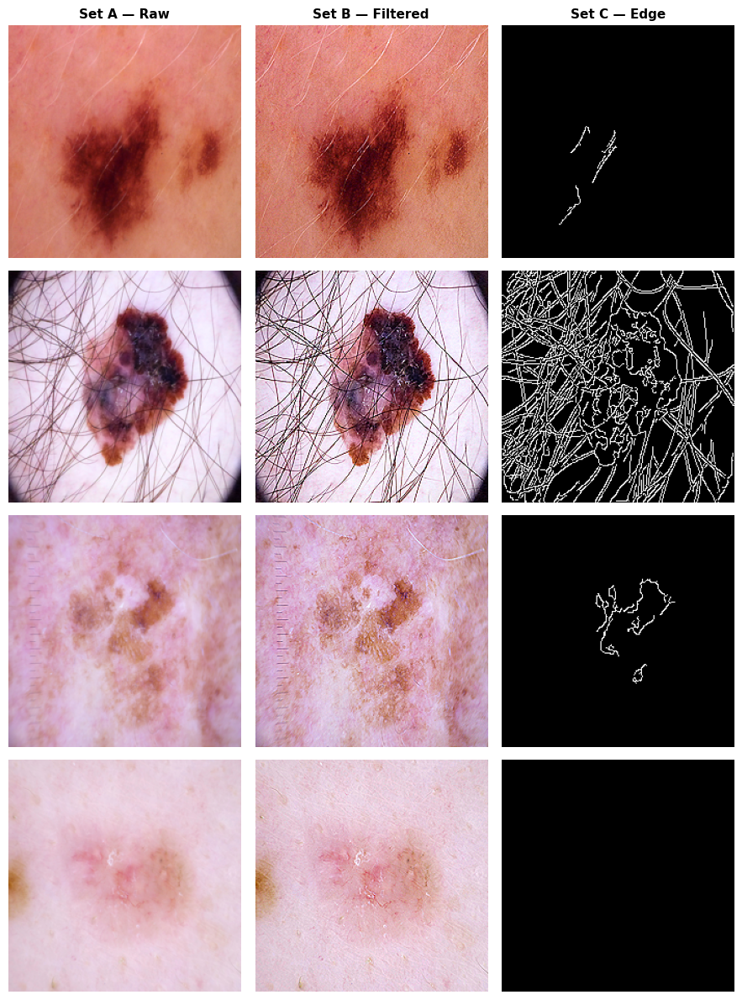

In [13]:
# ── Task 4: the three input representations ───────────────────────────────
def f_none(img):    return img
def f_sharpen(img):
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
    return np.clip(cv2.filter2D(img, -1, kernel), 0, 255).astype(np.uint8)

def f_canny3(img):
    e = ed_canny(img, **BEST_CANNY)
    return np.stack([e, e, e], axis=-1)

REPS = [("Raw", f_none), ("Filtered", f_sharpen), ("Edge", f_canny3)]

# Visual check: 4 classes × 3 representations
fig, axes = plt.subplots(len(sel_classes), 3, figsize=(9, 3 * len(sel_classes)))
for r, cls in enumerate(sel_classes):
    row = test_df[test_df["dx"] == cls].iloc[0]
    img = np.array(Image.open(row["image_path"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    for c, (rname, fn) in enumerate(REPS):
        axes[r, c].imshow(fn(img))
        if r == 0: axes[r, c].set_title(f"Set {'ABC'[c]} — {rname}", fontsize=11, fontweight="bold")
        if c == 0: axes[r, c].set_ylabel(cls, fontsize=11)
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()

# ── Array builder / loader (same as Lab 02) ───────────────────────────────
def build_array_split(dataframe, filter_fn):
    n = len(dataframe)
    imgs = np.zeros((n, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    labels = np.zeros(n, dtype=np.int64)
    for i, row in enumerate(dataframe.itertuples(index=False)):
        img = Image.open(row.image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        imgs[i] = filter_fn(np.array(img))
        labels[i] = label_to_idx[row.dx]
    return imgs, labels

class ArrayDataset(Dataset):
    def __init__(self, imgs, labels): self.imgs, self.labels = imgs, labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        t = torch.from_numpy(self.imgs[idx].astype(np.float32) / 255.0).permute(2, 0, 1)
        return (t - IMAGENET_MEAN) / IMAGENET_STD, self.labels[idx]

def make_loader(imgs, labels, shuffle):
    return DataLoader(ArrayDataset(imgs, labels), batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True,
                      persistent_workers=NUM_WORKERS > 0)


In [14]:
# ── Model builder + training loop (same hyperparameters as Lab 02) ────────
def get_model(name, num_classes=NUM_CLASSES):
    if name == "resnet101":
        m = torchvision.models.resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "densenet121":
        m = torchvision.models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    else:
        raise ValueError(name)
    return m.to(DEVICE)

def evaluate_loader(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE.type == "cuda"):
        for x, y in loader:
            out = model(x.to(DEVICE, non_blocking=True))
            all_logits.append(out.float().cpu()); all_labels.append(y)
    logits = torch.cat(all_logits); labels = torch.cat(all_labels)
    preds = logits.argmax(1).numpy()
    f1m = f1_score(labels.numpy(), preds, average="macro", zero_division=0)
    return f1m, logits, labels

def train_model(name, tag, train_loader, val_loader):
    print(f"\n{'='*66}\nTraining {name} | representation={tag}\n{'='*66}")
    model = get_model(name)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    scaler = torch.cuda.amp.GradScaler(enabled=DEVICE.type == "cuda")
    best_f1, best_state, wait = -1.0, None, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train(); t0 = time.time(); running = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE.type == "cuda"):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward(); scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            running += loss.item() * x.size(0)
        vf1, _, _ = evaluate_loader(model, val_loader); scheduler.step(vf1)
        print(f"Epoch {epoch:02d} | train_loss {running/len(train_loader.dataset):.4f} | val_macro_f1 {vf1:.4f} | {time.time()-t0:.1f}s")
        if vf1 > best_f1: best_f1, best_state, wait = vf1, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stop (best val_macro_f1={best_f1:.4f})"); break
    model.load_state_dict(best_state)
    torch.save(best_state, WORK_DIR / f"{name}_{tag}_best.pt")
    return model

def compute_metrics(y_true, y_pred, y_proba, n_classes=NUM_CLASSES):
    acc  = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0) * 100
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0) * 100
    f1w  = f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100
    f1m  = f1_score(y_true, y_pred, average="macro", zero_division=0) * 100
    try:
        auc = roc_auc_score(label_binarize(y_true, classes=list(range(n_classes))),
                            y_proba, average="macro", multi_class="ovr") * 100
    except Exception:
        auc = float("nan")
    return {"Accuracy": round(acc,2), "Precision": round(prec,2), "Recall": round(rec,2),
            "F1-score": round(f1w,2), "Macro-F1": round(f1m,2), "AUC": round(auc,2)}

@torch.no_grad()
def extract_features(extractor, loader):
    feats, labels = [], []
    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE.type == "cuda"):
        for x, y in loader:
            f = extractor(x.to(DEVICE, non_blocking=True))
            feats.append(f.float().cpu().numpy()); labels.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labels)

def measure_inference(model, loader):
    model.eval(); n = 0; t0 = time.perf_counter()
    with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE.type == "cuda"):
        for x, _ in loader:
            model(x.to(DEVICE, non_blocking=True)); n += x.size(0)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n * 1000   # ms per image


In [15]:
# ── Task 5 main loop: 3 representations × {SVM, RF, KNN, CNN-ResNet101, CNN-DenseNet121}
# Feature extractor for classical models: frozen ImageNet ResNet101 (same backbone for every set)
extractor = torchvision.models.resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
extractor.fc = nn.Identity()
for p in extractor.parameters(): p.requires_grad = False
extractor = extractor.to(DEVICE).eval()

CLASSIFIERS = {
    "SVM":           SVC(kernel="rbf", C=10, gamma="scale", probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
    "KNN":           KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}
CNN_MODELS = [("CNN Model 1 (ResNet101)", "resnet101"),
              ("CNN Model 2 (DenseNet121)", "densenet121")]

results_all, preds_store, ckpt_store = {}, {}, {}
rep_run_times = {}

for rep_name, rep_fn in REPS:
    tag = rep_name.lower()
    t_start = time.time()
    print(f"\n{'#'*70}\n# REPRESENTATION SET {rep_name} (A=Raw, B=Filtered, C=Edge)\n{'#'*70}")

    train_imgs, train_lbls = build_array_split(train_df, rep_fn)
    val_imgs,   val_lbls   = build_array_split(val_df,   rep_fn)
    test_imgs,  test_lbls  = build_array_split(test_df,  rep_fn)
    tr_ld = make_loader(train_imgs, train_lbls, True)
    va_ld = make_loader(val_imgs,   val_lbls,   False)
    te_ld = make_loader(test_imgs,  test_lbls,  False)

    results_all[rep_name], preds_store[rep_name] = {}, {}

    # ── Classical ML on frozen ResNet101 deep features ──
    X_tr, y_tr = extract_features(extractor, tr_ld)
    X_te, y_te = extract_features(extractor, te_ld)
    scaler = StandardScaler().fit(X_tr)
    X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

    for clf_name, clf in CLASSIFIERS.items():
        t0 = time.time(); clf.fit(X_tr_s, y_tr); fit_s = time.time() - t0
        t0 = time.time(); proba = clf.predict_proba(X_te_s) if hasattr(clf, "predict_proba") else None
        infer_ms = (time.time() - t0) / len(y_te) * 1000
        yp = proba.argmax(1) if proba is not None else clf.predict(X_te_s)
        m = compute_metrics(y_te, yp, proba)
        results_all[rep_name][clf_name] = {**m, "Train Time (s)": round(fit_s, 2),
                                           "Inference Time (ms/img)": round(infer_ms, 3)}
        preds_store[rep_name][clf_name] = (y_te, yp, proba)
        print(f"  {clf_name:14s} | Acc {m['Accuracy']:.2f} | MacroF1 {m['Macro-F1']:.2f} | "
              f"fit {fit_s:.1f}s | infer {infer_ms:.3f} ms/img")

    # ── CNN fine-tuning (same settings for every representation) ──
    for disp_name, arch in CNN_MODELS:
        t0 = time.time()
        model = train_model(arch, tag, tr_ld, va_ld)
        train_s = time.time() - t0
        _, logits, labels = evaluate_loader(model, te_ld)
        proba = F.softmax(logits, dim=1).numpy(); yp = proba.argmax(1)
        m = compute_metrics(labels.numpy(), yp, proba)
        infer_ms = measure_inference(model, te_ld)
        results_all[rep_name][disp_name] = {**m, "Train Time (s)": round(train_s, 2),
                                            "Inference Time (ms/img)": round(infer_ms, 2)}
        preds_store[rep_name][disp_name] = (labels.numpy(), yp, proba)
        ckpt_store[(rep_name, disp_name)] = copy.deepcopy(model.state_dict())
        print(f"  {disp_name:26s} | Acc {m['Accuracy']:.2f} | MacroF1 {m['Macro-F1']:.2f} | "
              f"train {train_s/60:.1f} min | infer {infer_ms:.2f} ms/img")
        del model; torch.cuda.empty_cache()

    rep_run_times[rep_name] = (time.time() - t_start) / 60
    print(f"Set {rep_name} done in {rep_run_times[rep_name]:.1f} min")
    del train_imgs, val_imgs, test_imgs, X_tr, X_te, tr_ld, va_ld, te_ld
    torch.cuda.empty_cache()
    import gc; gc.collect()

print("\nWall time per set (min):", {k: round(v,1) for k, v in rep_run_times.items()})



######################################################################
# REPRESENTATION SET Raw (A=Raw, B=Filtered, C=Edge)
######################################################################
  SVM            | Acc 77.58 | MacroF1 46.60 | fit 470.8s | infer 10.055 ms/img
  Random Forest  | Acc 72.12 | MacroF1 23.22 | fit 80.9s | infer 0.154 ms/img
  KNN            | Acc 70.20 | MacroF1 23.37 | fit 0.0s | infer 1.491 ms/img

Training resnet101 | representation=raw
Epoch 01 | train_loss 1.5968 | val_macro_f1 0.5162 | 84.2s
Epoch 02 | train_loss 0.7145 | val_macro_f1 0.6358 | 61.2s
Epoch 03 | train_loss 0.3299 | val_macro_f1 0.6284 | 59.2s
Epoch 04 | train_loss 0.1431 | val_macro_f1 0.6931 | 58.8s
Epoch 05 | train_loss 0.0582 | val_macro_f1 0.6738 | 59.6s
Epoch 06 | train_loss 0.0288 | val_macro_f1 0.6523 | 59.4s
Epoch 07 | train_loss 0.0187 | val_macro_f1 0.6812 | 58.8s
Epoch 08 | train_loss 0.0106 | val_macro_f1 0.6669 | 58.6s
  CNN Model 1 (ResNet101)    | Acc 79.80 | MacroF1 64.77

100%|██████████| 30.8M/30.8M [00:00<00:00, 192MB/s]


Epoch 01 | train_loss 1.3532 | val_macro_f1 0.5433 | 64.7s
Epoch 02 | train_loss 0.6198 | val_macro_f1 0.6314 | 41.6s
Epoch 03 | train_loss 0.3272 | val_macro_f1 0.6466 | 42.2s
Epoch 04 | train_loss 0.1621 | val_macro_f1 0.6571 | 42.2s
Epoch 05 | train_loss 0.0763 | val_macro_f1 0.7033 | 41.7s
Epoch 06 | train_loss 0.0353 | val_macro_f1 0.7141 | 42.2s
Epoch 07 | train_loss 0.0206 | val_macro_f1 0.7028 | 43.4s
Epoch 08 | train_loss 0.0121 | val_macro_f1 0.6827 | 41.7s
  CNN Model 2 (DenseNet121)  | Acc 81.92 | MacroF1 68.48 | train 6.0 min | infer 1.76 ms/img
Set Raw done in 25.9 min

######################################################################
# REPRESENTATION SET Filtered (A=Raw, B=Filtered, C=Edge)
######################################################################
  SVM            | Acc 77.07 | MacroF1 44.67 | fit 493.4s | infer 11.886 ms/img
  Random Forest  | Acc 71.62 | MacroF1 21.60 | fit 85.1s | infer 0.122 ms/img
  KNN            | Acc 70.71 | MacroF1 26.73 | fit 

## Task 5 — Classification Performance Comparison → Table 3

In [16]:
# ── Table 3: cross-lab comparison (Raw = Lab 01, Filtered = Lab 02, Edge = Lab 03)
MODEL_ROWS = ["SVM", "Random Forest", "KNN",
              "CNN Model 1 (ResNet101)", "CNN Model 2 (DenseNet121)"]

detailed_rows, t3_rows = [], []
for mname in MODEL_ROWS:
    per = {r: results_all[r][mname] for r in ["Raw", "Filtered", "Edge"]}
    for r in ["Raw", "Filtered", "Edge"]:
        detailed_rows.append({"Model": mname, "Set": r, **per[r]})
    t3_rows.append({
        "Model / Classifier": mname,
        "Accuracy Raw %":        per["Raw"]["Accuracy"],
        "Accuracy Filtered %":   per["Filtered"]["Accuracy"],
        "Accuracy Edge %":       per["Edge"]["Accuracy"],
        "Precision %":  round(np.mean([per[r]["Precision"]  for r in per]), 2),
        "Recall %":     round(np.mean([per[r]["Recall"]     for r in per]), 2),
        "F1-Score %":   round(np.mean([per[r]["F1-score"]   for r in per]), 2),
        "Training Time (s)": round(sum(per[r]["Train Time (s)"] for r in per), 1),
        "Inference Time (ms/img)": round(np.mean([per[r]["Inference Time (ms/img)"] for r in per]), 3),
    })

table3 = pd.DataFrame(t3_rows)
table3_detailed = pd.DataFrame(detailed_rows)
table3.to_csv(WORK_DIR / "table3_comparison.csv", index=False)
table3_detailed.to_csv(WORK_DIR / "table3_detailed.csv", index=False)

print("TABLE 3 — Cross-Lab Classification Performance Comparison")
print(table3.to_string(index=False))
print("\nDetailed per-set metrics saved to table3_detailed.csv")
table3


TABLE 3 — Cross-Lab Classification Performance Comparison
       Model / Classifier  Accuracy Raw %  Accuracy Filtered %  Accuracy Edge %  Precision %  Recall %  F1-Score %  Training Time (s)  Inference Time (ms/img)
                      SVM           77.58                77.07            67.88        68.58     74.18       69.35             1660.2                   11.667
            Random Forest           72.12                71.62            68.79        63.41     70.84       61.82              238.1                    0.132
                      KNN           70.20                70.71            63.33        60.87     68.08       63.55                0.0                    1.071
  CNN Model 1 (ResNet101)           79.80                80.00            35.35        74.21     65.05       67.31             1452.6                    2.527
CNN Model 2 (DenseNet121)           81.92                80.20            46.06        76.39     69.39       71.45             1029.5              

,Model / Classifier,Accuracy Raw %,Accuracy Filtered %,Accuracy Edge %,Precision %,Recall %,F1-Score %,Training Time (s),Inference Time (ms/img)
0,SVM,77.58,77.07,67.88,68.58,74.18,69.35,1660.2,11.667
1,Random Forest,72.12,71.62,68.79,63.41,70.84,61.82,238.1,0.132
2,KNN,70.20,70.71,63.33,60.87,68.08,63.55,0.0,1.071
3,CNN Model 1 (ResNet101),79.80,80.00,35.35,74.21,65.05,67.31,1452.6,2.527
4,CNN Model 2 (DenseNet121),81.92,80.20,46.06,76.39,69.39,71.45,1029.5,1.773


## Task 6 — Visual Comparison of Classification Results

Confusion matrices (raw / filtered / edge) + metric bar chart for the **best-performing model** (highest mean accuracy across the three sets).

Best model (mean accuracy over 3 sets): SVM


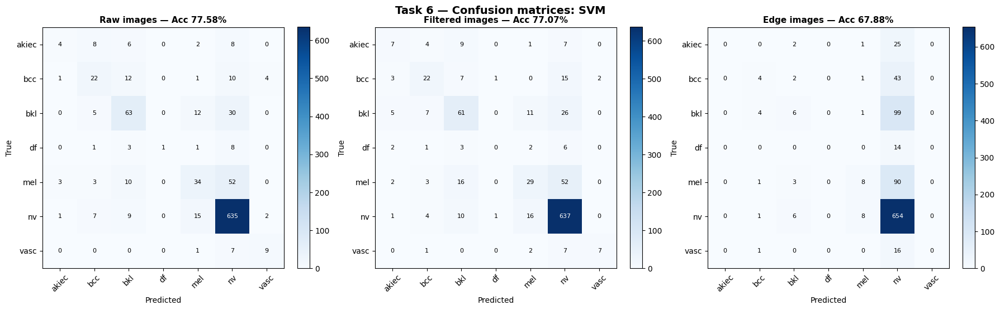

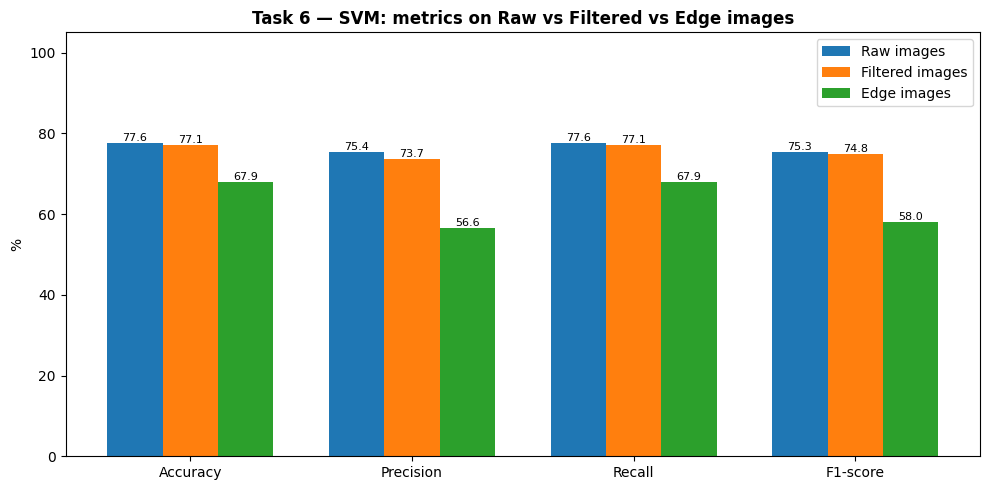


Raw images — per-class report (SVM)
              precision    recall  f1-score   support

       akiec      0.444     0.143     0.216        28
         bcc      0.478     0.440     0.458        50
         bkl      0.612     0.573     0.592       110
          df      1.000     0.071     0.133        14
         mel      0.515     0.333     0.405       102
          nv      0.847     0.949     0.895       669
        vasc      0.600     0.529     0.562        17

    accuracy                          0.776       990
   macro avg      0.642     0.434     0.466       990
weighted avg      0.754     0.776     0.753       990


Filtered images — per-class report (SVM)
              precision    recall  f1-score   support

       akiec      0.350     0.250     0.292        28
         bcc      0.524     0.440     0.478        50
         bkl      0.575     0.555     0.565       110
          df      0.000     0.000     0.000        14
         mel      0.475     0.284     0.356       102

In [17]:
# ── Task 6: confusion matrices + bar chart for the best model ─────────────
best_model = max(MODEL_ROWS, key=lambda m: np.mean([results_all[r][m]["Accuracy"]
                                                    for r in ["Raw", "Filtered", "Edge"]]))
print("Best model (mean accuracy over 3 sets):", best_model)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.4))
for ax, rname in zip(axes, ["Raw", "Filtered", "Edge"]):
    y_true, y_pred, _ = preds_store[rname][best_model]
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{rname} images — Acc {results_all[rname][best_model]['Accuracy']:.2f}%",
                 fontsize=11, fontweight="bold")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASSES, rotation=45); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > thresh else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f"Task 6 — Confusion matrices: {best_model}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(WORK_DIR / "task6_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Bar chart: Accuracy / Precision / Recall / F1 across the 3 sets ──
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics)); w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for i, rname in enumerate(["Raw", "Filtered", "Edge"]):
    vals = [results_all[rname][best_model][m] for m in metrics]
    bars = ax.bar(x + (i - 1) * w, vals, w, label=f"{rname} images")
    ax.bar_label(bars, fmt="%.1f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("%"); ax.set_ylim(0, 105)
ax.set_title(f"Task 6 — {best_model}: metrics on Raw vs Filtered vs Edge images",
             fontsize=12, fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig(WORK_DIR / "task6_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-class report for the best model on each set ──
for rname in ["Raw", "Filtered", "Edge"]:
    y_true, y_pred, _ = preds_store[rname][best_model]
    print(f"\n{'='*60}\n{rname} images — per-class report ({best_model})\n{'='*60}")
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3,
                                zero_division=0))


In [18]:
# ── Save / download all deliverables ──────────────────────────────────────
print("Files saved in:", WORK_DIR)
for f in sorted(os.listdir(WORK_DIR)):
    print("  -", f)

try:
    from google.colab import files
    for f in ["table1_noise.csv", "table2_canny.csv", "table3_comparison.csv",
              "table3_detailed.csv", "task1_edge_comparison.png",
              "task2_noise_edges.png", "task6_confusion_matrices.png",
              "task6_metrics_bar.png"]:
        files.download(str(WORK_DIR / f))
except Exception as e:
    print("(download skipped:", e, ")")

# Final summary
print("\n" + "="*70)
print("SUMMARY — mean accuracy per model across the 3 representations")
print("="*70)
for mname in MODEL_ROWS:
    accs = [results_all[r][mname]["Accuracy"] for r in ["Raw", "Filtered", "Edge"]]
    print(f"  {mname:28s} Raw {accs[0]:5.2f} | Filtered {accs[1]:5.2f} | Edge {accs[2]:5.2f}")


Files saved in: results
  - densenet121_edge_best.pt
  - densenet121_filtered_best.pt
  - densenet121_raw_best.pt
  - resnet101_edge_best.pt
  - resnet101_filtered_best.pt
  - resnet101_raw_best.pt
  - table1_noise.csv
  - table2_canny.csv
  - table3_comparison.csv
  - table3_detailed.csv
  - task1_edge_comparison.png
  - task2_noise_edges.png
  - task6_confusion_matrices.png
  - task6_metrics_bar.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


SUMMARY — mean accuracy per model across the 3 representations
  SVM                          Raw 77.58 | Filtered 77.07 | Edge 67.88
  Random Forest                Raw 72.12 | Filtered 71.62 | Edge 68.79
  KNN                          Raw 70.20 | Filtered 70.71 | Edge 63.33
  CNN Model 1 (ResNet101)      Raw 79.80 | Filtered 80.00 | Edge 35.35
  CNN Model 2 (DenseNet121)    Raw 81.92 | Filtered 80.20 | Edge 46.06
